In [3]:
import csv
import os
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Exploting and loading data

### Loading data

In [4]:
file_P = os.path.join(os.getcwd(),'Elspotprices2-1.csv')
print("file path: ", file_P)
df_prices = pd.read_csv(file_P)
df_prices["HourUTC"] = pd.to_datetime(df_prices["HourUTC"])
df_prices = df_prices.loc[(df_prices['PriceArea']=="DK2")][["HourUTC","SpotPriceDKK"]]
df_prices = df_prices.loc[df_prices["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_prices = df_prices.reset_index(drop=True)
file_P = os.path.join(os.getcwd(),'ProdConData-1.csv')
df_data = pd.read_csv(file_P)
df_data["HourUTC"] = pd.to_datetime(df_data["HourUTC"])
df_data = df_data.loc[df_data["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_data = df_data.reset_index(drop=True)


#inspecting the data
df_data.head()

# joining the prices in df_prices to the dataset in df_data
df_merged = pd.merge(df_prices, df_data, on='HourUTC')

# creating a dataset for dk2 only
df_dk2 = df_merged[df_merged['PriceArea']=='DK2']

# defining the training set and the test set according to the assignment
train_s = pd.Timestamp(dt.datetime(2023, 1, 1, 0, 0, 0))
train_e = pd.Timestamp(dt.datetime(2023, 11, 30, 23, 0, 0))
train_data = df_dk2[(df_dk2['HourUTC'] >= train_s) & (df_dk2['HourUTC'] <= train_e)]
test_data  = df_dk2[(df_dk2['HourUTC'] > train_e)]

file path:  /Users/augustpallesen/Documents/GitHub/MBML/August/Elspotprices2-1.csv


### Exploring data

In [5]:
print("Columns of training data: ", train_data.columns)
print("Shape of training data: ", train_data.shape)

Columns of training data:  Index(['HourUTC', 'SpotPriceDKK', 'HourDK', 'PriceArea', 'CentralPowerMWh',
       'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh',
       'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh',
       'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh',
       'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh',
       'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh',
       'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh',
       'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh',
       'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh',
       'GridLossDistributionMWh', 'PowerToHeatMWh'],
      dtype='object')
Shape of training data:  (8016, 29)


Text(0, 0.5, 'SpotPriceDKK')

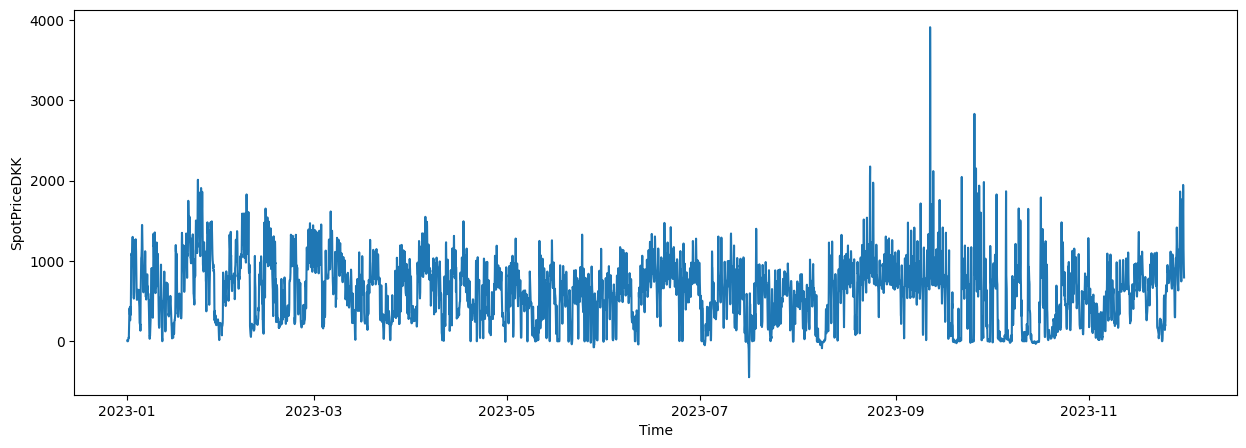

In [6]:
# plotting the data
plt.figure(figsize=(15,5))
plt.plot(train_data['HourUTC'], train_data['SpotPriceDKK'])
plt.xlabel('Time')
plt.ylabel('SpotPriceDKK')


### Picking featueres

As this is not the focus of our assisgment, we don't want to spend a lot of time picking features. So to make it simple we just plot the correlation matrix of all variables that have a correlation stronger than .3 to our target variable.


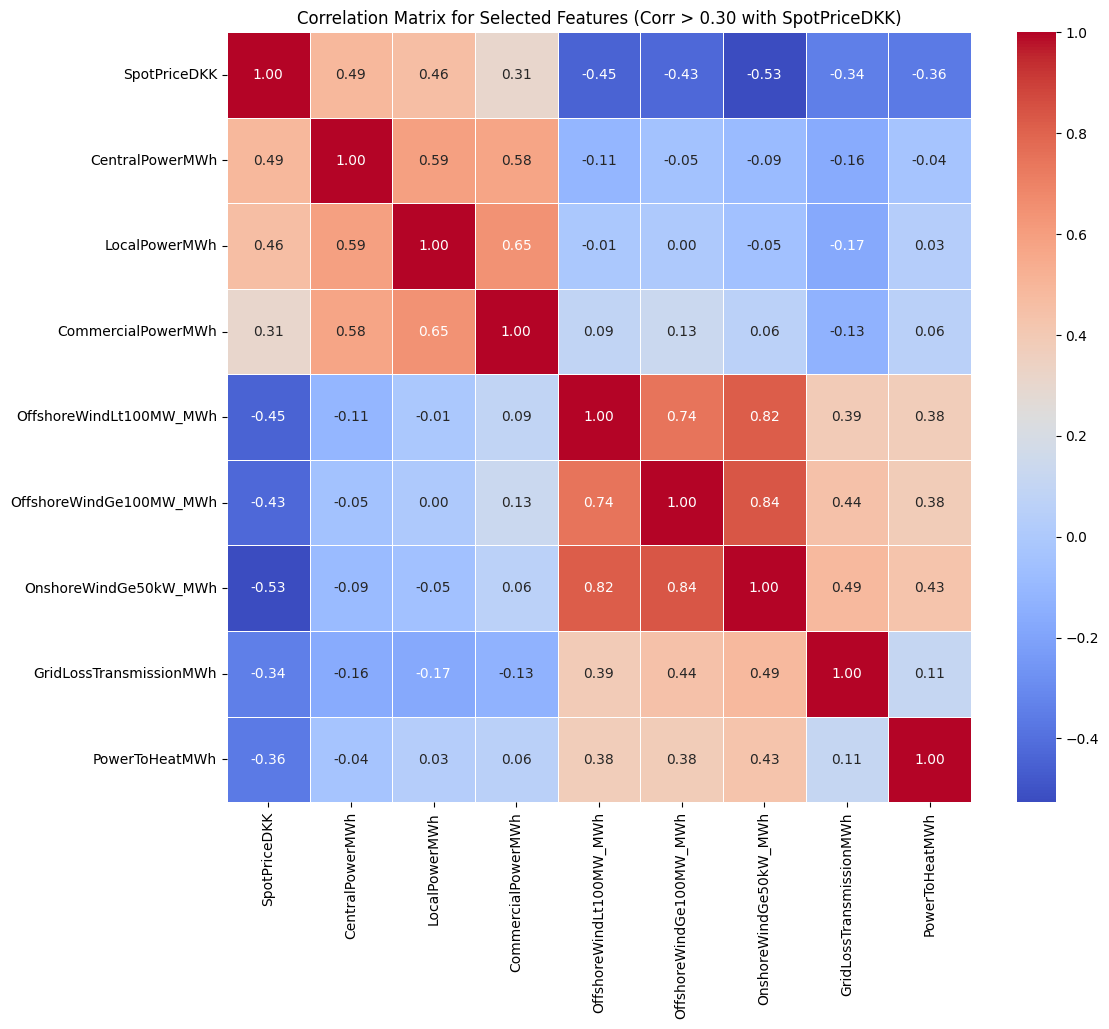

In [7]:
# Make a correlation matrix
# Drop all non-numeric columns
train_data_numeric = train_data.select_dtypes(include=[np.number])
correlation_matrix = train_data_numeric.corr()

# Filter to include only variables with absolute correlation > 0.30 to SpotPriceDKK
correlations_with_target = correlation_matrix['SpotPriceDKK']
selected_vars = correlations_with_target[abs(correlations_with_target) > 0.30].index
correlation_matrix_filtered = correlation_matrix.loc[selected_vars, selected_vars]

# Plot the filtered correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Selected Features (Corr > 0.30 with SpotPriceDKK)')
plt.show()


We decide on the following features:
 - OnshoreWindGe50kW_MWh
 - GridLossDistributionMWh,
 - ExchangeSE_MWh

# Models

The idea is to start with a simple model and iterativly make it more and more complex

### prepare data for Gaussian models

In [8]:
########## ---------- Preparing data and normalize ---------- ##########
# Pick features and target
features = ['OnshoreWindGe50kW_MWh', 'GridLossDistributionMWh', 'ExchangeSE_MWh']
time_variables = ['HourUTC']   # optional, see note below
target = 'SpotPriceDKK'

X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

# Normalize features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Normilize target
y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled.values, dtype=torch.float32)

### Simple linear model

The goal is to keep the framework the same for all model st. we can just change the 1 function and reuse the variational inference part.

In [9]:
########## ---------- Making regression model ---------- ##########
def bayesian_linear_regression(X, y=None):
    n_features = X.shape[1]

    # Initialize weights around 0 with std 1, and bias around 0 with std 10 to allow more flexibility
    weights = pyro.sample(
        "weights",
        dist.Normal(torch.zeros(n_features), torch.ones(n_features)).to_event(1)
    )
    bias = pyro.sample("bias", dist.Normal(torch.tensor(0.0), torch.tensor(10.0)))

    # Prior on observation noise
    sigma = pyro.sample("sigma", dist.LogNormal(torch.tensor(0.0), torch.tensor(1.0)))

    mean = X.matmul(weights) + bias

    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

    return mean


In [10]:
########## ---------- Using variational inference to fit the model ---------- ##########
pyro.clear_param_store()

guide = AutoDiagonalNormal(bayesian_linear_regression)
optimizer = Adam({"lr": 0.03})
svi = SVI(bayesian_linear_regression, guide, optimizer, loss=Trace_ELBO())

num_steps = 5000
for step in range(num_steps):
    loss = svi.step(X_train_t, y_train_t)
    if step % 500 == 0:
        print(f"Step {step} - ELBO loss: {loss:.2f}")


########## ---------- Posterior predictive ---------- ##########
predictive = Predictive(
    bayesian_linear_regression,
    guide=guide,
    num_samples=500,
    return_sites=("obs", "weights", "bias", "sigma")
)

samples = predictive(X_test_t)

# Posterior predictive samples for y on standardized scale
y_pred_samples_scaled = samples["obs"]            # shape: [500, N_test]
y_pred_mean_scaled = y_pred_samples_scaled.mean(0)

# Convert predictions back to original target scale
y_pred_mean = y_pred_mean_scaled.detach().cpu().numpy() * y_std + y_mean
y_test_np = y_test.values




Step 0 - ELBO loss: 47734.57
Step 500 - ELBO loss: 9059.14
Step 1000 - ELBO loss: 9033.10
Step 1500 - ELBO loss: 9038.04
Step 2000 - ELBO loss: 9032.43
Step 2500 - ELBO loss: 9040.65
Step 3000 - ELBO loss: 9034.22
Step 3500 - ELBO loss: 9032.12
Step 4000 - ELBO loss: 9031.81
Step 4500 - ELBO loss: 9035.95


Mean Squared Error: 97241.26320839816
R^2 Score: 0.3900261058427018


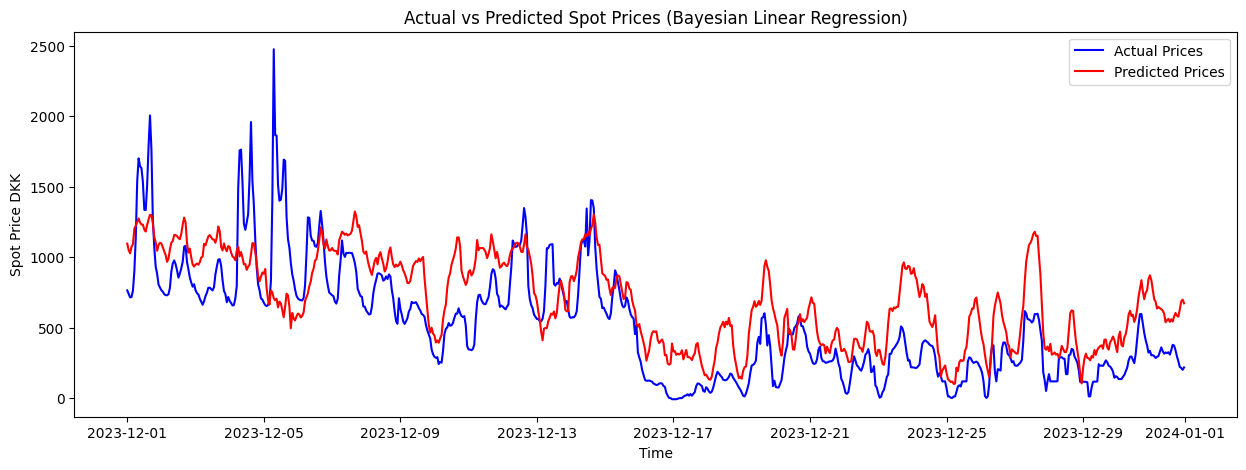

In [11]:
########## ---------- Evaluating the model ---------- ##########
mse = mean_squared_error(y_test_np, y_pred_mean)
r2 = r2_score(y_test_np, y_pred_mean)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# plotting regression results
plt.figure(figsize=(15,5))
plt.plot(test_data['HourUTC'], y_test_np, label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_mean, label='Predicted Prices', color='red')
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title('Actual vs Predicted Spot Prices (Bayesian Linear Regression)')
plt.legend()
plt.show()

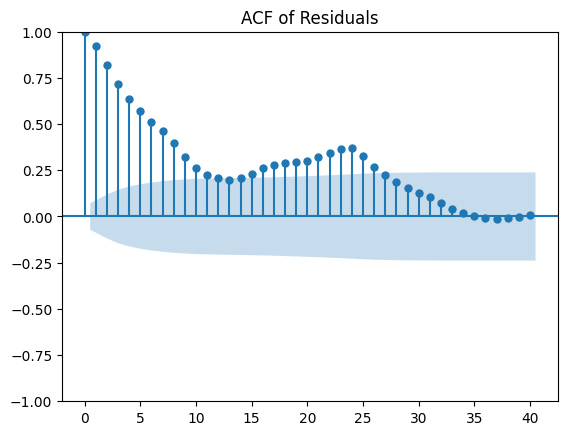

In [12]:
# plot the ACF plot of the residuals
residuals = y_test_np - y_pred_mean
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

### autoregressive exogenous input (ARX) model

We cannot use a simple AR model
$$ y_t = \sum_{m=1}^M \left( \beta_m y_t-m \right) + \epsilon $$
Since we have additional features that we would like to model we use the ARX model instead
$$
y_t = \alpha + \sum_{j=1}^{p} \phi_j\, y_{t-j} + \sum_{k=1}^{D} \beta_k\, x_{t,k} + \varepsilon_t,
\qquad t = p+1,\dots,T
$$

In [13]:

pyro.set_rng_seed(42)
pyro.clear_param_store()



########## ---------- Build lagged design matrices ---------- ##########
def make_arx_design(X_t, y_t, lag):
    """
    Build ARX design:
      response at time t
      predictors = [y_{t-1}, ..., y_{t-lag}, X_t]

    Args:
        X_t: torch.Tensor of shape [T, D]
        y_t: torch.Tensor of shape [T]
        lag: int, number of autoregressive lags

    Returns:
        X_design: torch.Tensor of shape [T-lag, lag + D]
        y_target: torch.Tensor of shape [T-lag]
    """
    if lag < 1:
        raise ValueError("lag must be >= 1")

    T = y_t.shape[0]
    if T <= lag:
        raise ValueError("Time series length must be greater than lag")

    y_lags = []
    for t in range(lag, T):
        # order: [y_{t-1}, y_{t-2}, ..., y_{t-lag}]
        lagged_vals = [y_t[t - j] for j in range(1, lag + 1)]
        y_lags.append(torch.stack(lagged_vals))

    y_lags = torch.stack(y_lags)         # [T-lag, lag]
    X_trim = X_t[lag:]                   # [T-lag, D]
    X_design = torch.cat([y_lags, X_trim], dim=1)

    y_target = y_t[lag:]                 # [T-lag]
    return X_design, y_target

########## ---------- Bayesian ARX model in Pyros ---------- ##########
def bayesian_arx_model(X, y=None):
    """
    X: [N, P] design matrix = [lagged y | exogenous features]
    y: [N]
    """
    N, P = X.shape

    # Priors
    intercept = pyro.sample("intercept", dist.Normal(0.0, 1.0))
    weights = pyro.sample("weights", dist.Normal(torch.zeros(P), torch.ones(P)).to_event(1))
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))

    mean = intercept + X.matmul(weights)

    with pyro.plate("data", N):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)


########## ---------- Train with variational inference ---------- ##########
def fit_bayesian_arx(X_train_t, y_train_t, lag=3, lr=0.02, num_steps=3000):
    X_design, y_target = make_arx_design(X_train_t, y_train_t, lag)

    guide = AutoNormal(bayesian_arx_model)
    optim = Adam({"lr": lr})
    svi = SVI(bayesian_arx_model, guide, optim, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_design, y_target)
        losses.append(loss)

        if step % 500 == 0:
            print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

    return {
        "guide": guide,
        "losses": losses,
        "lag": lag,
        "X_design": X_design,
        "y_target": y_target,
    }


########## ---------- Posterior prediction on a prepared design matrix ---------- ##########
def posterior_predict(guide, X_design, num_samples=500):
    predictive = Predictive(
        bayesian_arx_model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("obs", "intercept", "weights", "sigma"),
    )
    samples = predictive(X_design)

    y_samples = samples["obs"]                  # [S, N]
    y_mean = y_samples.mean(0)                  # [N]
    y_std = y_samples.std(0)                    # [N]

    return {
        "y_samples": y_samples,
        "y_mean": y_mean,
        "y_std": y_std,
        "posterior_samples": samples,
    }

########## ---------- Prepare train/test designs with same lag ---------- ##########
def prepare_train_test_arx(X_train_t, y_train_t, X_test_t, y_test_t, lag):
    X_train_design, y_train_target = make_arx_design(X_train_t, y_train_t, lag)
    X_test_design, y_test_target = make_arx_design(X_test_t, y_test_t, lag)
    return X_train_design, y_train_target, X_test_design, y_test_target


########## ---------- Utility: inverse-transform target back to original units ---------- ##########
def invert_target_scaling(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean


########## ---------- Example run ---------- ##########
lag = 11   # <-- change this to control memory / number of lags

X_train_design, y_train_target, X_test_design, y_test_target = prepare_train_test_arx(
    X_train_t, y_train_t, X_test_t, y_test_t, lag=lag
)

fit_result = fit_bayesian_arx(X_train_t, y_train_t, lag=lag, lr=0.02, num_steps=3000)
guide = fit_result["guide"]

pred_test = posterior_predict(guide, X_test_design, num_samples=1000)

# Predictions in scaled space
y_test_pred_mean_scaled = pred_test["y_mean"]
y_test_pred_std_scaled = pred_test["y_std"]

# Back to original target scale
y_test_pred_mean = invert_target_scaling(y_test_pred_mean_scaled, y_mean, y_std)
y_test_pred_std = y_test_pred_std_scaled * y_std
y_test_true = invert_target_scaling(y_test_target, y_mean, y_std)

rmse = torch.sqrt(torch.mean((y_test_pred_mean - y_test_true) ** 2))
mae = torch.mean(torch.abs(y_test_pred_mean - y_test_true))

print(f"\nTest RMSE: {rmse.item():.4f}")
print(f"Test MAE : {mae.item():.4f}")

Step    0  ELBO loss = 10680.29
Step  500  ELBO loss = 1893.11
Step 1000  ELBO loss = 1825.38
Step 1500  ELBO loss = 2075.61
Step 2000  ELBO loss = 1907.11
Step 2500  ELBO loss = 1816.35

Test RMSE: 98.0072
Test MAE : 63.6074


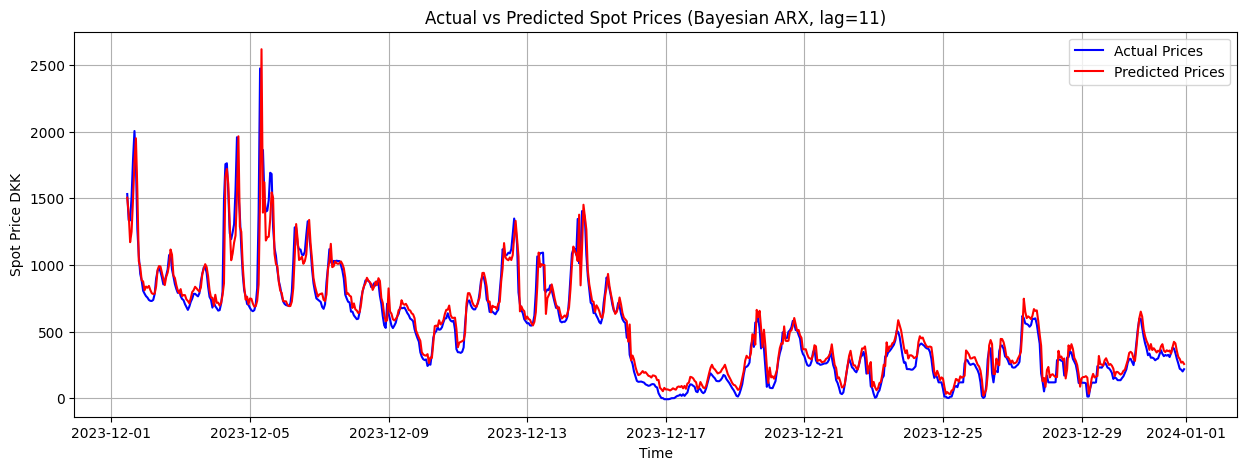

In [14]:
time_test = test_data['HourUTC'].iloc[lag:].reset_index(drop=True)

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(time_test, y_test_pred_mean.detach().numpy(), label='Predicted Prices', color='red')

plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Actual vs Predicted Spot Prices (Bayesian ARX, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()

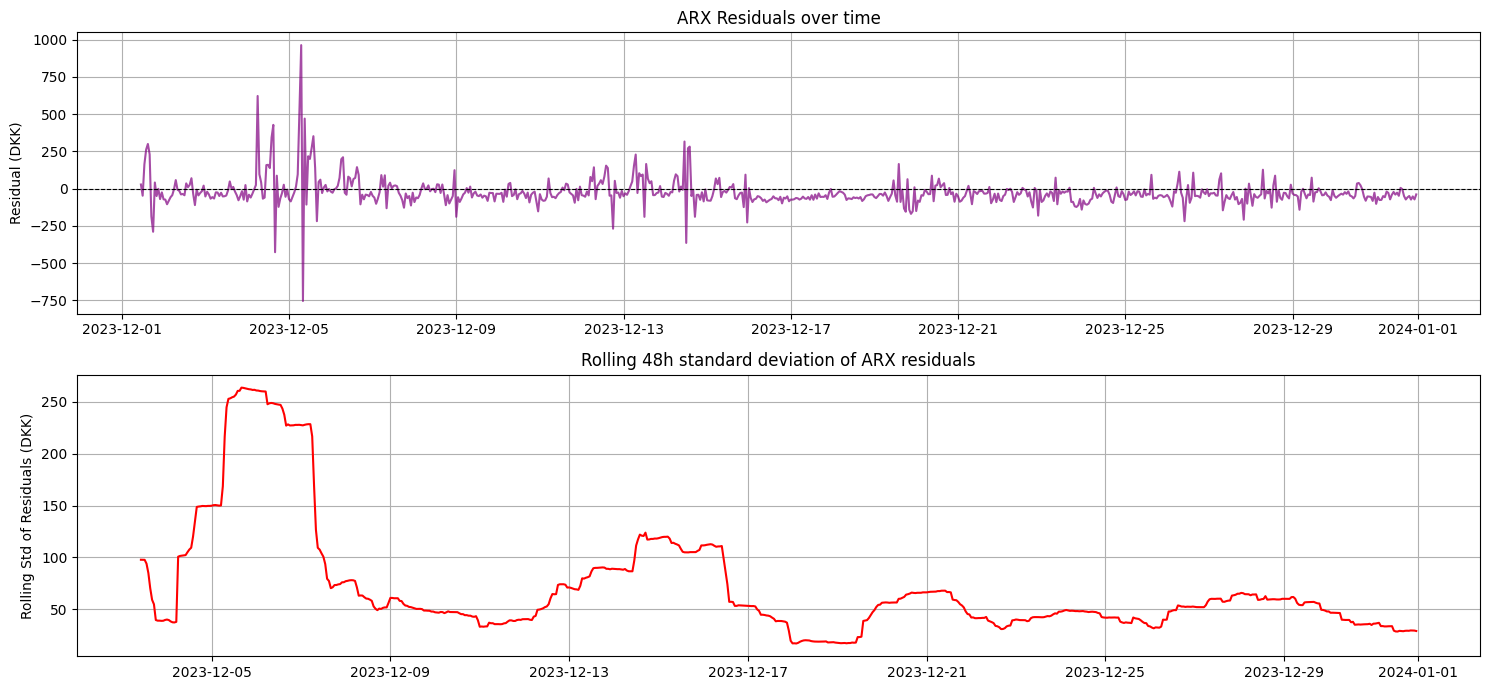

In [15]:
residuals = (y_test_true - y_test_pred_mean).detach().numpy()
time_axis = test_data['HourUTC'].iloc[lag:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

# Raw residuals
axes[0].plot(time_axis, residuals, color='purple', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Residual (DKK)')
axes[0].set_title('ARX Residuals over time')
axes[0].grid(True)

# Rolling std — window of e.g. 48 hours
residual_series = pd.Series(residuals, index=time_axis)
rolling_std = residual_series.rolling(window=48).std()
axes[1].plot(time_axis, rolling_std, color='red')
axes[1].set_ylabel('Rolling Std of Residuals (DKK)')
axes[1].set_title('Rolling 48h standard deviation of ARX residuals')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Markov Model

#### The core idea

Electricity prices don't stay constant — they shift between different "moods". During windy nights, supply is high and prices are low. During cold, still evenings, demand spikes and prices are high. In between there is a normal baseline.

A **Hidden Markov Model (HMM)** formalises this by assuming there are **K hidden regimes** (we use K = 3: low / medium / high). At every hour the market is secretly in one of these regimes, and the regime determines what price we are likely to see.

Two things govern the dynamics:

- **Transitions** — if we are in a "high price" regime today, how likely are we to stay there tomorrow vs. fall back to normal? This is captured by a *transition matrix* $A$, where each entry $A_{ij}$ is the probability of moving from regime $i$ to regime $j$:

$$z_t \mid z_{t-1} = i \;\sim\; \text{Categorical}(A_{i,\cdot})$$

- **Emissions** — once we know the regime $z_t$, the price is drawn from a Gaussian centred on that regime's typical price level $\mu_k$, with spread $\sigma_k$:

$$y_t \mid z_t = k \;\sim\; \mathcal{N}(\mu_k,\, \sigma_k^2)$$

The full joint over a sequence of $T$ prices is therefore:

$$p(y_{1:T}) = \sum_{z_{1:T}} p(z_1) \prod_{t=2}^{T} A_{z_{t-1}, z_t} \prod_{t=1}^{T} \mathcal{N}(y_t;\, \mu_{z_t}, \sigma_{z_t}^2)$$

where the sum runs over all $K^T$ possible regime sequences. Pyro's `DiscreteHMM` computes this efficiently using the forward algorithm, so we never have to enumerate them explicitly.

Crucially, **we never observe the regime directly** — the model has to infer it purely from the price history. After training, it will have learnt: (a) the typical price $\mu_k$ and spread $\sigma_k$ in each regime, and (b) the transition matrix $A$ capturing how persistently the market stays in each regime before switching.

In [16]:
from pyro.distributions import DiscreteHMM

K = 3   # three hidden regimes: low / medium / high prices

def simple_markov_model(y_obs=None, T=None):
    """
    Generative story
    ----------------
    1. Start in some initial regime (drawn from pi).
    2. At each hour, stay in the current regime or switch (governed by matrix A).
    3. Draw the price from a Gaussian centred on that regime's mean.

    We never observe the regime — only the prices.
    Pyro's DiscreteHMM marginalises over all possible regime sequences for us.
    """
    if y_obs is not None:
        T = y_obs.shape[0]

    # Which regime are we likely in at hour 0?
    initial_logits = pyro.sample(
        "initial_logits", dist.Normal(torch.zeros(K), torch.ones(K)).to_event(1)
    )

    # Transition matrix: A[i, j] = log-probability of moving from regime i to regime j
    transition_logits = pyro.sample(
        "transition_logits", dist.Normal(torch.zeros(K, K), torch.ones(K, K)).to_event(2)
    )

    # Typical price level in each regime (in normalised units)
    emission_loc = pyro.sample(
        "emission_loc", dist.Normal(torch.zeros(K), 2.0 * torch.ones(K)).to_event(1)
    )

    # How much prices vary *within* each regime
    emission_scale = pyro.sample(
        "emission_scale", dist.LogNormal(torch.zeros(K), 0.5 * torch.ones(K)).to_event(1)
    )

    # Each regime defines a Gaussian over prices
    obs_dist = dist.Normal(emission_loc, emission_scale)

    # DiscreteHMM stitches together the transitions and emissions into a
    # single distribution over the full price sequence, marginalising out regimes
    hmm = DiscreteHMM(initial_logits, transition_logits, obs_dist)
    pyro.sample("y", hmm, obs=y_obs)


Step    0  ELBO loss = 11578.42
Step  500  ELBO loss = 6475.82
Step 1000  ELBO loss = 6477.66
Step 1500  ELBO loss = 6474.20
Step 2000  ELBO loss = 6467.86
Step 2500  ELBO loss = 6478.57


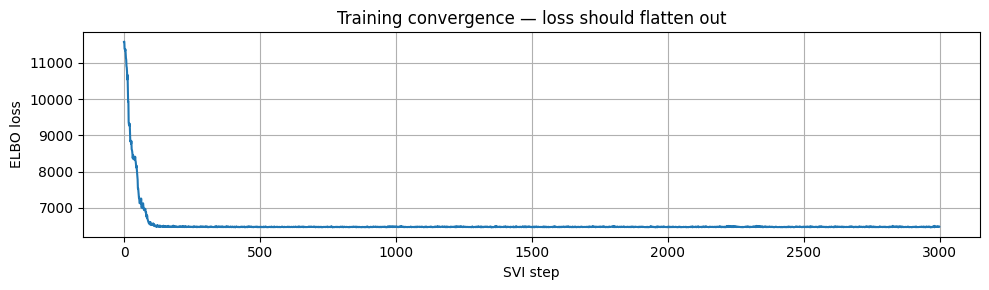

In [17]:
# SVI (variational inference) learns the best values for all the unknowns:
# emission means, emission spreads, transition probabilities, and initial distribution.

pyro.clear_param_store()
pyro.set_rng_seed(42)

guide_hmm    = AutoDiagonalNormal(simple_markov_model)
optimizer_hmm = Adam({"lr": 0.05})
svi_hmm      = SVI(simple_markov_model, guide_hmm, optimizer_hmm, loss=Trace_ELBO())

num_steps_hmm = 3000
losses_hmm = []
for step in range(num_steps_hmm):
    loss = svi_hmm.step(y_train_t)
    losses_hmm.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_hmm)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training convergence — loss should flatten out")
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
# ── Step 1: read out what the model learnt ───────────────────────────────────

predictive_hmm = Predictive(
    simple_markov_model, guide=guide_hmm, num_samples=500,
    return_sites=["initial_logits", "transition_logits", "emission_loc", "emission_scale"]
)
post_samples = predictive_hmm(y_obs=y_train_t)

# Take the posterior mean of each parameter
init_logits_map  = post_samples["initial_logits"].mean(0).detach()
trans_logits_map = post_samples["transition_logits"].mean(0).detach()
emit_loc_map     = post_samples["emission_loc"].mean(0).detach()
emit_scale_map   = post_samples["emission_scale"].mean(0).detach()

# Sort regimes from lowest to highest price so the labels make intuitive sense
order            = emit_loc_map.argsort()
emit_loc_map     = emit_loc_map[order]
emit_scale_map   = emit_scale_map[order]
init_logits_map  = init_logits_map[order]
trans_logits_map = trans_logits_map[order][:, order]

# Convert transition logits to actual probabilities
trans_probs = torch.softmax(trans_logits_map, dim=-1)

print("Typical price in each regime (normalised scale — 0 = training mean):")
for k, (loc, scale) in enumerate(zip(emit_loc_map, emit_scale_map)):
    name = ['Low', 'Medium', 'High'][k]
    print(f"  Regime {k} ({name}):  mean = {loc:.2f},  std = {scale:.2f}")

print("\nTransition matrix  (row = current regime, column = next regime):")
print("  (high diagonal = regime is sticky / persistent)")
print(trans_probs.numpy().round(3))


# ── Step 2: make one-step-ahead predictions using the forward filter ─────────
#
# At each hour t we ask: "given everything we have seen so far (y_1 ... y_{t-1}),
# which regime are we probably in right now?"  Then we predict the price as the
# weighted average of all regime means, using those regime probabilities as weights.
#
# This is called the *forward filter* — it updates our belief about the current
# regime every time we see a new price.

def forward_filter_predict(y, initial_logits, transition_logits, emission_loc, emission_scale):
    T     = y.shape[0]
    log_pi = torch.log_softmax(initial_logits, dim=-1)    # starting regime probs  [K]
    log_A  = torch.log_softmax(transition_logits, dim=-1) # transition log-probs   [K, K]

    def log_emit(t):
        # How likely is each regime to produce the price we actually saw at time t?
        return dist.Normal(emission_loc, emission_scale).log_prob(y[t])  # [K]

    predictions = []

    # t=0: we haven't seen anything yet, so predict from the prior over regimes
    pred_probs = torch.softmax(log_pi, dim=-1)
    predictions.append((pred_probs * emission_loc).sum())

    # Update our belief using the actual price at t=0
    log_alpha = log_pi + log_emit(0)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)  # normalise

    for t in range(1, T):
        # Propagate belief one step forward through the transition matrix
        log_pred = torch.logsumexp(log_alpha.unsqueeze(-1) + log_A, dim=0)
        log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)
        pred_probs = torch.softmax(log_pred, dim=-1)

        # Predicted price = expected value under the predicted regime distribution
        predictions.append((pred_probs * emission_loc).sum())

        # Then update with the actual observed price
        log_alpha = log_pred + log_emit(t)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    return torch.stack(predictions)  # [T]


y_pred_scaled_hmm = forward_filter_predict(
    y_test_t, init_logits_map, trans_logits_map, emit_loc_map, emit_scale_map
)

# Convert predictions back to DKK
y_pred_hmm = y_pred_scaled_hmm.detach().numpy() * y_std + y_mean
y_test_np2 = y_test.values

rmse_hmm = float(((y_pred_hmm - y_test_np2) ** 2).mean() ** 0.5)
mae_hmm  = float(abs(y_pred_hmm - y_test_np2).mean())
print(f"\nTest RMSE: {rmse_hmm:.2f} DKK")
print(f"Test MAE : {mae_hmm:.2f} DKK")


Typical price in each regime (normalised scale — 0 = training mean):
  Regime 0 (Low):  mean = -1.11,  std = 0.41
  Regime 1 (Medium):  mean = 0.13,  std = 0.33
  Regime 2 (High):  mean = 1.20,  std = 0.65

Transition matrix  (row = current regime, column = next regime):
  (high diagonal = regime is sticky / persistent)
[[0.939 0.055 0.006]
 [0.049 0.879 0.072]
 [0.002 0.131 0.867]]

Test RMSE: 187.89 DKK
Test MAE : 125.40 DKK


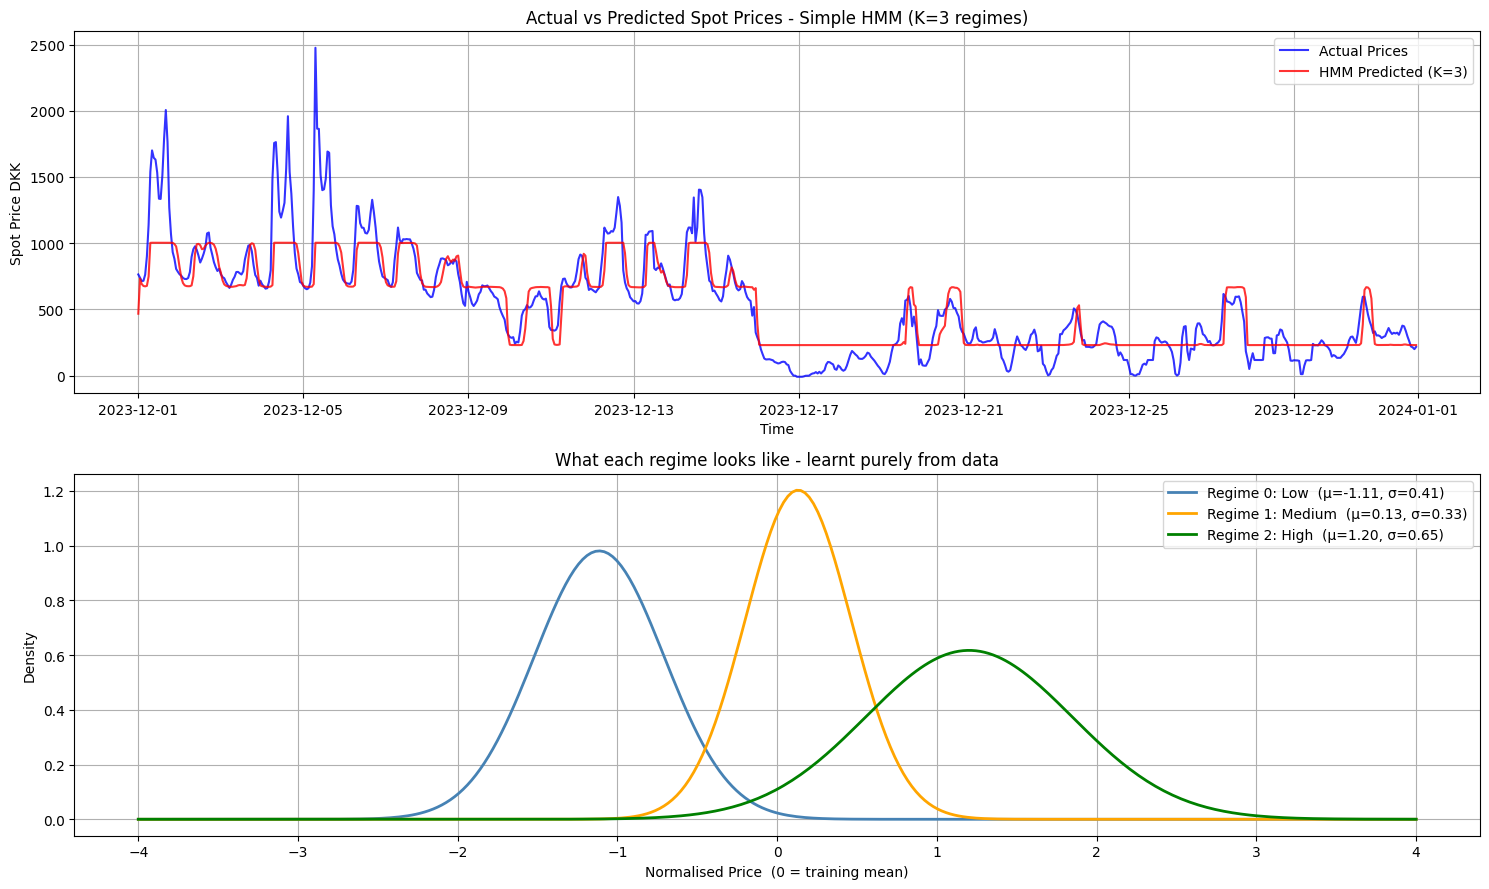

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ── Top: actual vs predicted ─────────────────────────────────────────────────
axes[0].plot(test_data['HourUTC'], y_test_np2, label='Actual Prices', color='blue', alpha=0.8)
axes[0].plot(test_data['HourUTC'], y_pred_hmm, label=f'HMM Predicted (K={K})', color='red', alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Spot Price DKK')
axes[0].set_title(f'Actual vs Predicted Spot Prices - Simple HMM (K={K} regimes)')
axes[0].legend()
axes[0].grid(True)

# ── Bottom: the three learnt regime distributions ────────────────────────────
x_grid       = torch.linspace(-4, 4, 300)
regime_names = ['Low', 'Medium', 'High']
colors       = ['steelblue', 'orange', 'green']

for k in range(K):
    pdf   = dist.Normal(emit_loc_map[k], emit_scale_map[k]).log_prob(x_grid).exp().numpy()
    label = f'Regime {k}: {regime_names[k]}  (μ={emit_loc_map[k]:.2f}, σ={emit_scale_map[k]:.2f})'
    axes[1].plot(x_grid.numpy(), pdf, color=colors[k], label=label, linewidth=2)

axes[1].set_xlabel('Normalised Price  (0 = training mean)')
axes[1].set_ylabel('Density')
axes[1].set_title('What each regime looks like - learnt purely from data')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Reading the regime plot

Each bell curve above is the price distribution the model assigned to one of the three hidden regimes. Remember, **the model never saw regime labels** — it discovered these clusters on its own purely from the training prices.

| Regime | Colour | What it means |
|--------|--------|---------------|
| **Low** | Blue | Hours when prices were well below average — typically high renewable output or low demand (nights, windy periods). The narrow bell means prices are *consistently* low in this regime. |
| **Medium** | Orange | The "normal" operating regime centred on the training mean. Most hours fall here. |
| **High** | Green | Hours with above-average prices — often peak demand or low wind. The *wider* bell (larger σ) shows that high-price periods are more volatile and harder to predict. |

The **transition matrix** printed above tells you how sticky each regime is: a high diagonal value means "once you're in this regime, you tend to stay there". Electricity markets typically show very high persistence — regimes can last for days.

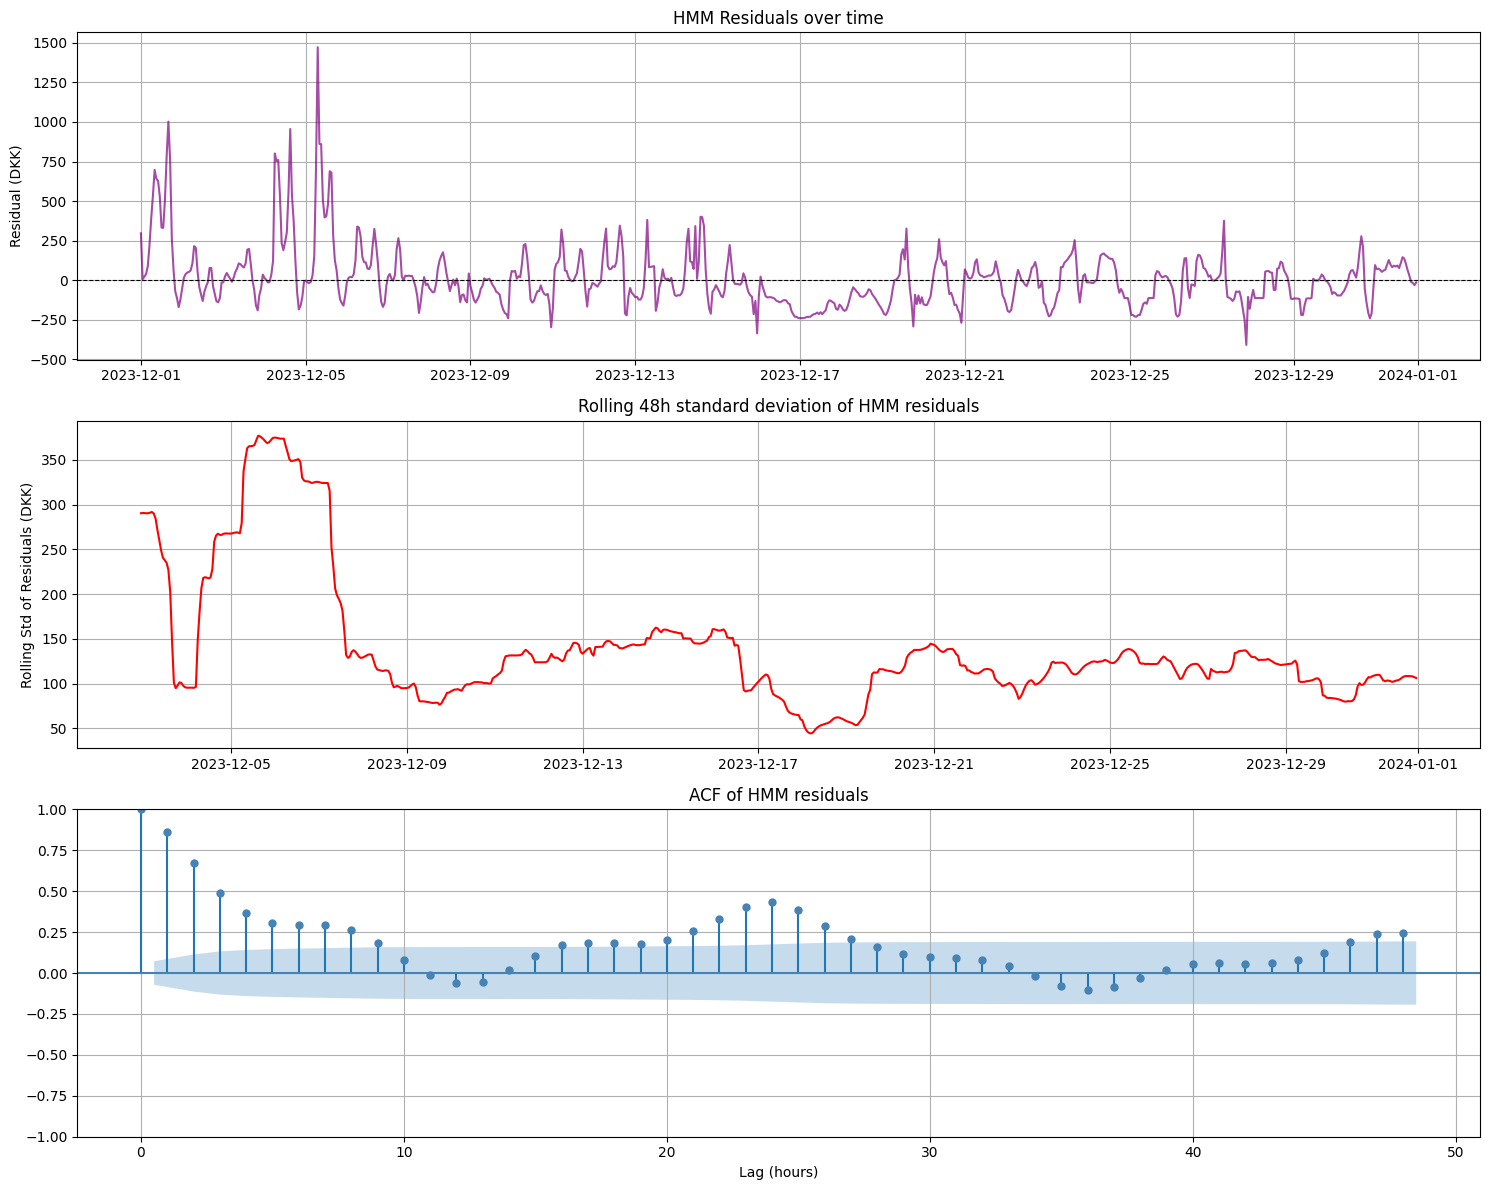

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

residuals_hmm = y_test_np2 - y_pred_hmm
residual_series_hmm = pd.Series(residuals_hmm, index=test_data['HourUTC'])
rolling_std_hmm = residual_series_hmm.rolling(window=48).std()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ── Residuals over time ───────────────────────────────────────────────────────
axes[0].plot(test_data['HourUTC'], residuals_hmm, color='purple', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Residual (DKK)')
axes[0].set_title('HMM Residuals over time')
axes[0].grid(True)

# ── Rolling std ───────────────────────────────────────────────────────────────
axes[1].plot(test_data['HourUTC'], rolling_std_hmm, color='red')
axes[1].set_ylabel('Rolling Std of Residuals (DKK)')
axes[1].set_title('Rolling 48h standard deviation of HMM residuals')
axes[1].grid(True)

# ── ACF of residuals ──────────────────────────────────────────────────────────
plot_acf(residuals_hmm, lags=48, ax=axes[2], color='steelblue')
axes[2].set_title('ACF of HMM residuals')
axes[2].set_xlabel('Lag (hours)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### New improved model

In [25]:
from pyro.distributions import DiscreteHMM

K = 3      # hidden regimes
M = 11      # number of lags


def ar_hmm_model(y_obs=None):
    """
    Autoregressive HMM.

    Modified PGM:

        h_t-1  ->  h_t  ->  y_t
                              ^
                              |
                      y_{t-1}, ..., y_{t-M}

    The hidden state chooses the regime, but the observation also depends
    directly on previous observed prices.
    """

    T = y_obs.shape[0]

    # Target values: y_M, ..., y_T
    y_target = y_obs[M:]

    # Lag matrix:
    # row t contains [y_{t-1}, y_{t-2}, ..., y_{t-M}]
    y_lags = torch.stack(
        [y_obs[M - j:T - j] for j in range(1, M + 1)],
        dim=1
    )

    N = y_target.shape[0]

    # --------------------------------------------------
    # Initial distribution p(h_{M+1})
    # --------------------------------------------------
    initial_logits = pyro.sample(
        "initial_logits",
        dist.Normal(torch.zeros(K), torch.ones(K)).to_event(1)
    )

    # --------------------------------------------------
    # Transition model p(h_t | h_{t-1})
    # --------------------------------------------------
    B_transition_logits = pyro.sample(
        "B_transition_logits",
        dist.Normal(torch.zeros(K, K), torch.ones(K, K)).to_event(2)
    )

    # --------------------------------------------------
    # State-specific emission intercepts
    # --------------------------------------------------
    C_emission_mean = pyro.sample(
        "C_emission_mean",
        dist.Normal(torch.zeros(K), 2.0 * torch.ones(K)).to_event(1)
    )

    # --------------------------------------------------
    # State-specific emission noise
    # --------------------------------------------------
    C_emission_scale = pyro.sample(
        "C_emission_scale",
        dist.LogNormal(torch.zeros(K), 0.5 * torch.ones(K)).to_event(1)
    )

    # --------------------------------------------------
    # New part: state-specific autoregressive coefficients
    #
    # phi[k, j] controls how lag j affects y_t
    # when the hidden state is k.
    # --------------------------------------------------
    AR_lag_weights = pyro.sample(
        "AR_lag_weights",
        dist.Normal(
            torch.zeros(K, M),
            0.3 * torch.ones(K, M)
        ).to_event(2)
    )

    # --------------------------------------------------
    # Build time-dependent emission means
    #
    # loc[t, k] =
    #     mu_k + phi_{k,1} y_{t-1} + ... + phi_{k,M} y_{t-M}
    # --------------------------------------------------
    emission_loc = (
        C_emission_mean.unsqueeze(0)
        + y_lags @ AR_lag_weights.T
    )

    emission_scale = C_emission_scale.unsqueeze(0).expand(N, K)

    C_emission_distribution = dist.Normal(
        emission_loc,
        emission_scale
    )

    hmm_distribution = DiscreteHMM(
        initial_logits=initial_logits,
        transition_logits=B_transition_logits,
        observation_dist=C_emission_distribution
    )

    pyro.sample(
        "y",
        hmm_distribution,
        obs=y_target
    )

Step    0  ELBO loss = 10989.76
Step  500  ELBO loss = -630.13
Step 1000  ELBO loss = -810.99
Step 1500  ELBO loss = -1432.46
Step 2000  ELBO loss = -1138.44
Step 2500  ELBO loss = -1394.59


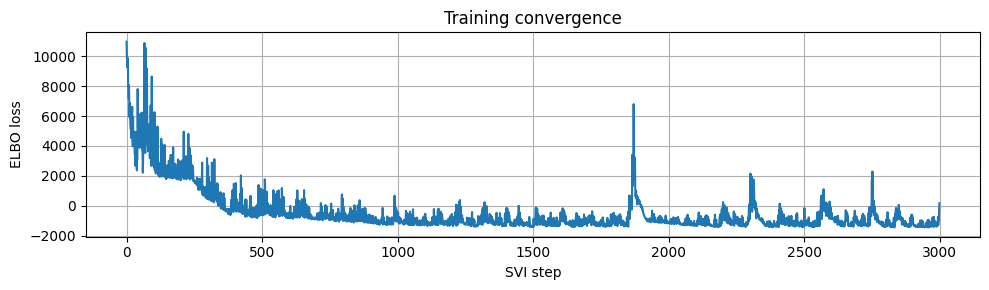

In [26]:
# SVI (variational inference) learns the best values for all the unknowns:
# emission means, emission spreads, transition probabilities, and initial distribution.

pyro.clear_param_store()
pyro.set_rng_seed(42)

guide_hmm    = AutoDiagonalNormal(ar_hmm_model)
optimizer_hmm = Adam({"lr": 0.05})
svi_hmm      = SVI(ar_hmm_model, guide_hmm, optimizer_hmm, loss=Trace_ELBO())

num_steps_hmm = 3000
losses_hmm = []
for step in range(num_steps_hmm):
    loss = svi_hmm.step(y_train_t)
    losses_hmm.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_hmm)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Training convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


Typical price in each regime (normalised scale — 0 = training mean):
  Regime 0 (Low):  mean = -0.00,  std = 0.07
  Regime 1 (Medium):  mean = 0.01,  std = 0.20
  Regime 2 (High):  mean = 0.06,  std = 0.63

State-specific AR coefficients:
  Regime 0 (Low): phi = [ 1.25e+00 -2.85e-01 -2.70e-02 -2.00e-02 -2.00e-03 -2.80e-02  1.00e-02
 -9.00e-03 -1.00e-03  1.20e-02 -3.00e-02]
  Regime 1 (Medium): phi = [ 1.59  -0.732  0.007  0.048 -0.008 -0.008  0.012  0.003 -0.015  0.134
 -0.083]
  Regime 2 (High): phi = [ 0.976 -0.282 -0.038 -0.126  0.102 -0.075  0.003 -0.099  0.073  0.014
  0.155]

Transition matrix  (row = current regime, column = next regime):
  (high diagonal = regime is sticky / persistent)
[[0.764 0.199 0.037]
 [0.144 0.783 0.073]
 [0.2   0.159 0.641]]

Test RMSE: 97.02 DKK
Test MAE : 58.85 DKK


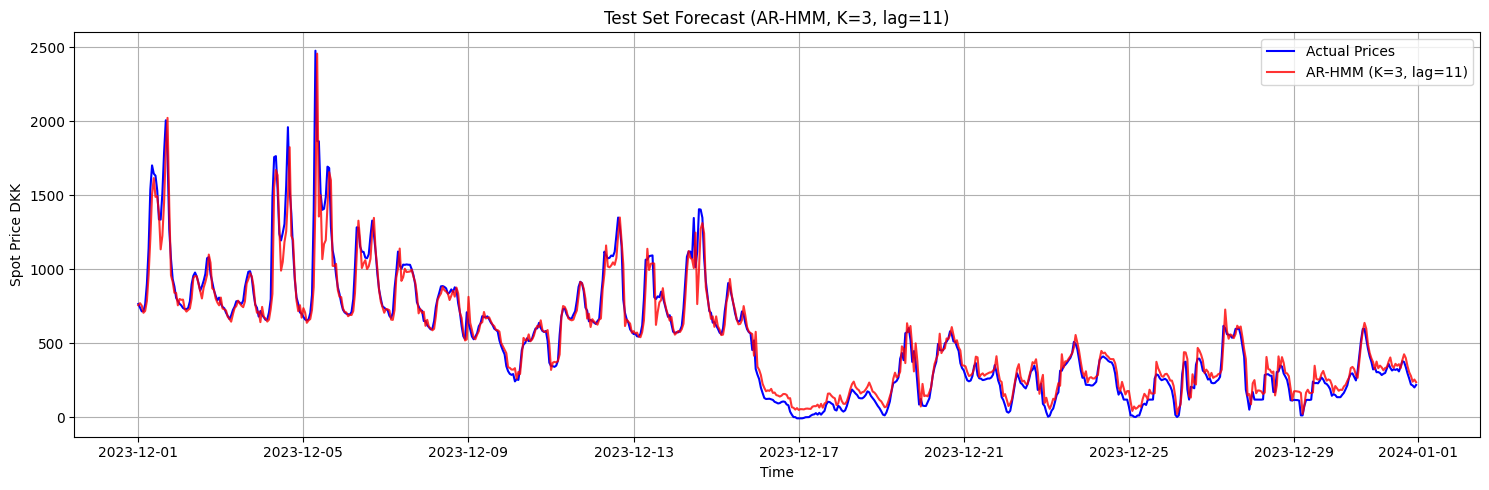

In [27]:
# ── Step 1: read out what the AR-HMM learnt ──────────────────────────────────

predictive_hmm = Predictive(
    ar_hmm_model,
    guide=guide_hmm,
    num_samples=500,
    return_sites=[
        "initial_logits",
        "B_transition_logits",
        "C_emission_mean",
        "C_emission_scale",
        "AR_lag_weights",
    ],
)

post_samples = predictive_hmm(y_obs=y_train_t)

# Posterior means
init_logits_map  = post_samples["initial_logits"].mean(0).detach()          # [K]
trans_logits_map = post_samples["B_transition_logits"].mean(0).detach()     # [K, K]
mu_map           = post_samples["C_emission_mean"].mean(0).detach()         # [K]
sigma_map        = post_samples["C_emission_scale"].mean(0).detach()        # [K]
phi_map          = post_samples["AR_lag_weights"].mean(0).detach()          # [K, M]


# ── Helper: build lag matrix ────────────────────────────────────────────────
def make_lag_matrix(y, M):
    """
    Row t contains [y_{t-1}, y_{t-2}, ..., y_{t-M}].
    Returns targets y[M:] and lags with shape [T-M, M].
    """
    y_target = y[M:]
    y_lags = torch.stack(
        [y[M - j: -j] for j in range(1, M + 1)],
        dim=1
    )
    return y_target, y_lags


# Build training emission means so we can sort regimes by typical predicted price
y_train_target, y_train_lags = make_lag_matrix(y_train_t, M)

train_emission_loc = (
    mu_map.unsqueeze(0) +
    y_train_lags @ phi_map.T
)  # [T-M, K]

typical_regime_mean = train_emission_loc.mean(dim=0)  # [K]

# Sort regimes from lowest to highest typical price
order = typical_regime_mean.argsort()

mu_map           = mu_map[order]
sigma_map        = sigma_map[order]
phi_map          = phi_map[order]
init_logits_map  = init_logits_map[order]
trans_logits_map = trans_logits_map[order][:, order]
typical_regime_mean = typical_regime_mean[order]

# Convert transition logits to probabilities
trans_probs = torch.softmax(trans_logits_map, dim=-1)

print("Typical price in each regime (normalised scale — 0 = training mean):")
for k, (loc, scale) in enumerate(zip(typical_regime_mean, sigma_map)):
    name = ["Low", "Medium", "High"][k]
    print(f"  Regime {k} ({name}):  mean = {loc:.2f},  std = {scale:.2f}")

print("\nState-specific AR coefficients:")
for k in range(K):
    name = ["Low", "Medium", "High"][k]
    print(f"  Regime {k} ({name}): phi = {phi_map[k].numpy().round(3)}")

print("\nTransition matrix  (row = current regime, column = next regime):")
print("  (high diagonal = regime is sticky / persistent)")
print(trans_probs.numpy().round(3))

# ── Step 2: one-step-ahead predictions with AR emissions ─────────────────────

def forward_filter_predict_ar_hmm(
    y,
    y_lags,
    initial_logits,
    transition_logits,
    mu,
    sigma,
    phi
):
    """
    Forward filter for AR-HMM.

    y:      observed target values, shape [N]
    y_lags: lagged observations, shape [N, M]

    emission_loc[t, k] =
        mu[k] + phi[k,1] y_{t-1} + ... + phi[k,M] y_{t-M}
    """

    N = y.shape[0]

    log_pi = torch.log_softmax(initial_logits, dim=-1)       # [K]
    log_A  = torch.log_softmax(transition_logits, dim=-1)    # [K, K]

    emission_loc = (
        mu.unsqueeze(0) +
        y_lags @ phi.T
    )  # [N, K]

    emission_scale = sigma.unsqueeze(0).expand(N, K)  # [N, K]

    def log_emit(t):
        return dist.Normal(
            emission_loc[t],
            emission_scale[t]
        ).log_prob(y[t])  # [K]

    predictions = []

    # t = 0: predict before seeing y_0
    pred_probs = torch.softmax(log_pi, dim=-1)
    predictions.append((pred_probs * emission_loc[0]).sum())

    # update with observed y_0
    log_alpha = log_pi + log_emit(0)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    for t in range(1, N):

        # predict hidden state at time t
        log_pred = torch.logsumexp(
            log_alpha.unsqueeze(-1) + log_A,
            dim=0
        )
        log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)

        pred_probs = torch.softmax(log_pred, dim=-1)

        # predicted price uses time-specific AR emission mean
        predictions.append((pred_probs * emission_loc[t]).sum())

        # update using actual y_t
        log_alpha = log_pred + log_emit(t)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    return torch.stack(predictions), emission_loc

# ── Step 3: build lagged test data ───────────────────────────────────────────
#
# To predict the first test point, we need the last M training observations.
# Then for later test points, we use previous observed test prices.

y_context = torch.cat([y_train_t[-M:], y_test_t])

y_test_target = y_context[M:]  # this is exactly y_test_t

y_test_lags = torch.stack(
    [y_context[M - j: -j] for j in range(1, M + 1)],
    dim=1
)

# ── Step 4: predict ─────────────────────────────────────────────────────────

y_pred_scaled_hmm, test_emission_loc = forward_filter_predict_ar_hmm(
    y=y_test_target,
    y_lags=y_test_lags,
    initial_logits=init_logits_map,
    transition_logits=trans_logits_map,
    mu=mu_map,
    sigma=sigma_map,
    phi=phi_map,
)

# Convert predictions back to DKK
y_pred_AR_hmm = y_pred_scaled_hmm.detach().numpy() * y_std + y_mean
y_test_np2 = y_test.values

rmse_hmm = float(((y_pred_AR_hmm - y_test_np2) ** 2).mean() ** 0.5)
mae_hmm  = float(abs(y_pred_AR_hmm - y_test_np2).mean())

print(f"\nTest RMSE: {rmse_hmm:.2f} DKK")
print(f"Test MAE : {mae_hmm:.2f} DKK")


plt.figure(figsize=(15, 5))
plt.plot(test_data["HourUTC"], y_test_np2, label="Actual Prices", color="blue")
plt.plot(test_data["HourUTC"], y_pred_AR_hmm, label=f"AR-HMM (K={K}, lag={M})", color="red", alpha=0.8)

plt.xlabel("Time")
plt.ylabel("Spot Price DKK")
plt.title(f"Test Set Forecast (AR-HMM, K={K}, lag={M})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Diagnostics

FileNotFoundError: [Errno 2] No such file or directory: 'AR-HMM/transition_matrix.png'

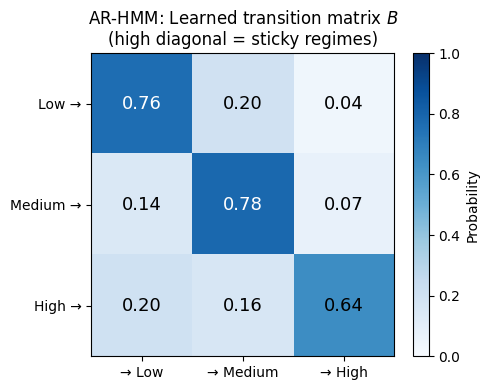

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

regime_names = ['Low', 'Medium', 'High']
colors       = ['steelblue', 'darkorange', 'forestgreen']

# ── 1. Transition matrix heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
B = trans_probs.numpy()
im = ax.imshow(B, cmap='Blues', vmin=0, vmax=1)
for i in range(K):
    for j in range(K):
        ax.text(j, i, f'{B[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color='black' if B[i,j] < 0.7 else 'white')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels([f'→ {n}' for n in regime_names])
ax.set_yticklabels([f'{n} →' for n in regime_names])
ax.set_title('AR-HMM: Learned transition matrix $B$\n(high diagonal = sticky regimes)')
plt.colorbar(im, ax=ax, label='Probability')
plt.tight_layout()
plt.savefig('AR-HMM/transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. Per-regime AR lag coefficients ────────────────────────────────────────
fig, axes = plt.subplots(1, K, figsize=(15, 4), sharey=True)
lags = np.arange(1, M + 1)
for k in range(K):
    axes[k].bar(lags, phi_map[k].numpy(), color=colors[k],
                alpha=0.8, edgecolor='black', linewidth=0.5)
    axes[k].axhline(0, color='black', linewidth=0.8)
    axes[k].set_title(
        f'Regime {k}: {regime_names[k]}\n'
        f'$\\mu$={mu_map[k]:.2f}, $\\sigma$={sigma_map[k]:.2f}'
    )
    axes[k].set_xlabel('Lag $j$')
    axes[k].set_xticks(lags)
    axes[k].grid(True, alpha=0.3, axis='y')
axes[0].set_ylabel('AR coefficient $A_k$')
fig.suptitle('Per-regime autoregressive lag coefficients — AR-HMM', fontsize=13)
plt.tight_layout()
plt.savefig('AR-HMM/ar_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Regime belief state over test period ───────────────────────────────────
# Re-run the forward filter collecting alpha_t at each step

log_pi = torch.log_softmax(init_logits_map, dim=-1)
log_A  = torch.log_softmax(trans_logits_map, dim=-1)

N = y_test_target.shape[0]
emission_scale = sigma_map.unsqueeze(0).expand(N, K)

def log_emit(t):
    return dist.Normal(test_emission_loc[t], emission_scale[t]).log_prob(y_test_target[t])

beliefs = []
log_alpha = log_pi + log_emit(0)
log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)
beliefs.append(torch.softmax(log_alpha, dim=-1).numpy().copy())

for t in range(1, N):
    log_pred = torch.logsumexp(log_alpha.unsqueeze(-1) + log_A, dim=0)
    log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)
    log_alpha = log_pred + log_emit(t)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)
    beliefs.append(torch.softmax(log_alpha, dim=-1).numpy().copy())

beliefs = np.array(beliefs)  # [N, K]

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# Top: actual vs predicted
axes[0].plot(test_data['HourUTC'], y_test_np2,    color='black',  linewidth=1.2, label='Actual')
axes[0].plot(test_data['HourUTC'], y_pred_AR_hmm, color='crimson', linewidth=1.0, alpha=0.8, label='AR-HMM forecast')
axes[0].set_ylabel('Spot price (DKK)')
axes[0].set_title('AR-HMM: Actual prices and inferred regime beliefs over test period')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Bottom: belief per regime
for k in range(K):
    axes[1].plot(test_data['HourUTC'], beliefs[:, k],
                 color=colors[k], label=regime_names[k], linewidth=1.2)
axes[1].set_ylabel('Posterior belief $P(h_t = k \\mid y_{1:t})$')
axes[1].set_xlabel('Time')
axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AR-HMM/regime_beliefs.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Most likely regime per hour (hard assignment) ─────────────────────────
hard_regimes = beliefs.argmax(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].plot(test_data['HourUTC'], y_test_np2, color='black', linewidth=1.2)
axes[0].set_ylabel('Spot price (DKK)')
axes[0].set_title('AR-HMM: Price coloured by most likely regime')
axes[0].grid(True, alpha=0.3)

for k in range(K):
    mask = hard_regimes == k
    t_vals = test_data['HourUTC'].values
    axes[1].scatter(t_vals[mask], np.full(mask.sum(), k),
                    color=colors[k], s=8, label=regime_names[k])

axes[1].set_yticks(range(K))
axes[1].set_yticklabels(regime_names)
axes[1].set_ylabel('Regime')
axes[1].set_xlabel('Time')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AR-HMM/regime_assignment.png', dpi=150, bbox_inches='tight')
plt.show()

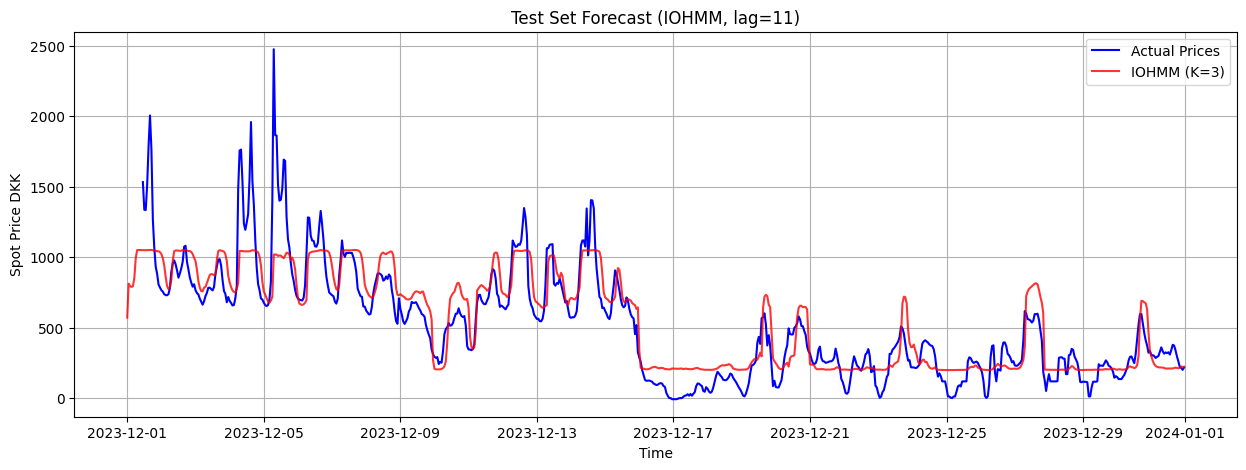

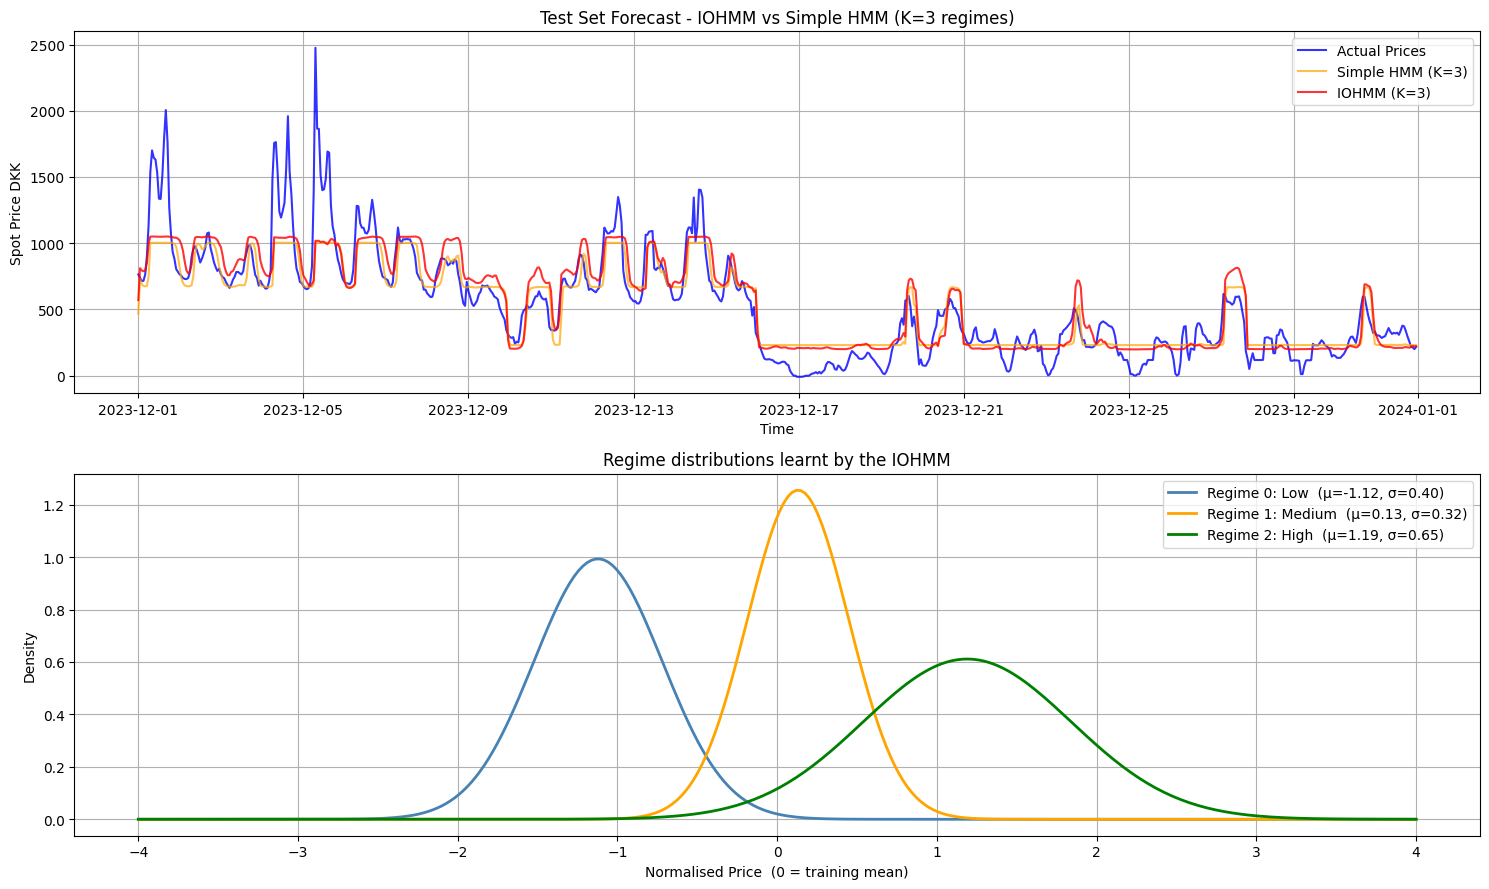

In [28]:

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_iohmm, label=f'IOHMM (K={K})',       color='red',    alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Test Set Forecast (IOHMM, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ── Top: actual vs predicted ─────────────────────────────────────────────────
axes[0].plot(test_data['HourUTC'], y_test_np_io, label='Actual Prices', color='blue', alpha=0.8)
axes[0].plot(test_data['HourUTC'], y_pred_hmm,   label=f'Simple HMM (K={K})',  color='orange', alpha=0.7)
axes[0].plot(test_data['HourUTC'], y_pred_iohmm, label=f'IOHMM (K={K})',       color='red',    alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Spot Price DKK')
axes[0].set_title(f'Test Set Forecast - IOHMM vs Simple HMM (K={K} regimes)')
axes[0].legend()
axes[0].grid(True)

# ── Bottom: the three learnt regime distributions ────────────────────────────
x_grid       = torch.linspace(-4, 4, 300)
regime_names = ['Low', 'Medium', 'High']
colors       = ['steelblue', 'orange', 'green']

for k in range(K):
    pdf   = dist.Normal(emit_loc_iohmm[k], emit_scale_iohmm[k]).log_prob(x_grid).exp().numpy()
    label = f'Regime {k}: {regime_names[k]}  (μ={emit_loc_iohmm[k]:.2f}, σ={emit_scale_iohmm[k]:.2f})'
    axes[1].plot(x_grid.numpy(), pdf, color=colors[k], label=label, linewidth=2)

axes[1].set_xlabel('Normalised Price  (0 = training mean)')
axes[1].set_ylabel('Density')
axes[1].set_title('Regime distributions learnt by the IOHMM')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
